# Exploración y preprocesamiento del Bonn EEG Dataset para la clasificación de estados ictales e interictales

## Objetivo

El objetivo de este trabajo es realizar la exploración y el preprocesamiento de señales electroencefalográficas (EEG) provenientes del Bonn EEG Dataset para una futura clasificación binaria entre estados **ictales** e **interictales**.

Para ello se implementa un pipeline reproducible que incluye:

- Carga y exploración de datos.
- Identificación del desbalance de clases.
- División en entrenamiento, validación y prueba.
- Filtrado y eliminación de ruido.
- Verificación de segmentación.
- Normalización de señales.
- Comparación antes y después del preprocesamiento.

Los subconjuntos utilizados para la clasificación son:

- **Set C (N): Interictal**
- **Set D (F): Interictal**
- **Set E (S): Ictal**

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis


In [2]:
#Conexión con google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
base_path = '/content/drive/MyDrive/Proyecto_RecPatrones/Avance_2/Dataset-BONN'

# 1. Carga y descripción del dataset

El dataset utilizado en este proyecto es una colección de señales EEG del **Conjunto de Datos de Bonn (Bonn EEG Dataset)**, conocido por su uso en la investigación de la epilepsia. Procede de la base de datos de electroencefalogramas del Hospital Universitario de Bonn de libre acceso (https://www.kaggle.com/datasets/quands/eeg-dataset?select=Dataset)
Este dataset sirve de estándar para la investigación de la epilepsia y es ideal para el desarrollo y evaluación de algoritmos de clasificación de señales EEG debido a sus clases bien definidas (ictales vs. no ictales) y su estructura clara.

**Detalles:**

*   **Tamaño Total:** Contiene 500 registros.
*   **Número de Muestras por Señal:** Cada señal tiene 4097 de muestra.
*   **Clases o Etiquetas:** El dataset se ha categorizado en dos clases binarias:
    *   `No ictal`: Incluye segmentos de EEG de voluntarios sanos y de pacientes con epilepsia durante periodos interictales.
    *   `Ictal`: Corresponde a segmentos de EEG registrados durante una crisis epiléptica.
*   **Formato de los Archivos:** Archivos `.txt`.
*   **Tipo de Dato:** Señal biomédica EEG.
*   **Distribución de Clases:**
    *   `No ictal`: 400 registros (80%)
    *   `Ictal`: 100 registros (20%)

    Visualmente se muestra el desbalance de clases, con la clase 'No ictal' siendo mayoritaria. Esto será importante considerar en la fase de modelado.

**Estadísticas Descriptivas Promedio por Clase (de la sección 6):**

| Clase    | Media ($\mu V$) | Desviación Estándar ($\mu V$) | Varianza | Mínimo ($\mu V$) | Máximo ($\mu V$) | Asimetría | Curtosis |
|:---------|:---------------|:-------------------------------|:---------|:-----------------|:-----------------|:----------|:---------|
| Ictal    | -4.749         | 306.573                        | 115659.632 | -948.910           | 910.050          | -0.060    | 0.428    |
| No ictal | -8.464         | 54.567                         | 4088.426 | -205.945           | 194.472          | -0.009    | 0.603    |

Estas estadísticas muestran diferencias notables entre las clases, especialmente en la desviación estándar, que es significativamente mayor para las señales ictales, lo que sugiere una mayor variabilidad y actividad de alta amplitud durante las crisis.

In [13]:
dataset_summary = pd.DataFrame({"Subconjunto":["Set A", "Set B", "Set C", "Set D", "Set E"],
                                "Descripción":["Sano - Ojos abiertos", "Sano - Ojos cerrados",
                                               "Interictal - Región control", "Interictal - Zona focal",
                                               "Ictal - Crisis activa"],
                                "Número de señales":[100, 100, 100, 100, 100]})
display(dataset_summary)

,Subconjunto,Descripción,Número de señales
0,Set A,Sano - Ojos abiertos,100
1,Set B,Sano - Ojos cerrados,100
2,Set C,Interictal - Región control,100
3,Set D,Interictal - Zona focal,100
4,Set E,Ictal - Crisis activa,100


## 1.1 Carga de señales

Se cargan únicamente los subconjuntos N, F y S, correspondientes a los estados interictales e ictales considerados en este estudio.

In [15]:
# Mapeo de carpetas según el planteamiento binario (Bonn EEG)
# Z (A), O (B), N (C), F (D) -> No ictal
# S (E) -> Ictal
folder_mapping = {
    "N":"Interictal",
    "F":"Interictal",
    "S":"Ictal"
}

# Parámetros fisiológicos
fs = 173.61 # Frecuencia de muestreo en Hz
n_samples = 4097 # Muestras por segmento

signals = []
labels = []

for folder, label in folder_mapping.items():
    folder_path = os.path.join(base_path, folder)
    for filename in os.listdir(folder_path):
        signal = np.loadtxt(os.path.join(folder_path, filename))
        signals.append(signal)
        labels.append(label)

# Resumen de carga
total = len(labels)
interictal = labels.count("Interictal")
ictal = labels.count("Ictal")

print("="*60)
print("Resumen de carga del dataset")
print("="*60)
print(f"Total de señales EEG     : {total}")
print(f"Interictal               : {interictal}")
print(f"Ictal                    : {ictal}")
print()
print(f"Frecuencia de muestreo   : {fs}Hz")
print(f"Muestras por señal       : {len(signals[0])} muestras")
print(f"Duración por señal       : {len(signals[0])/fs:.2f}s")

RESUMEN DE CARGA DEL DATASET
Total de señales EEG     : 300
Interictal               : 200
Ictal                    : 100

Frecuencia de muestreo   : 173.61Hz
Muestras por señal       : 4097 muestras
Duración por señal       : 23.60s


# 2. Exploración de datos

Antes del preprocesamiento se realiza una exploración inicial para identificar la distribución de clases y las características estadísticas de las señales EEG.

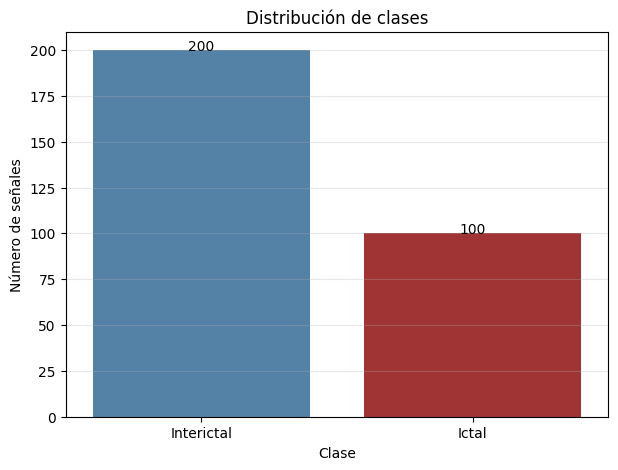


Proporción de clases (%)
Clase
Interictal    66.67
Ictal         33.33
Name: proportion, dtype: float64


In [16]:
# Distribución de clases
df_labels = pd.DataFrame({"Clase": labels})

plt.figure(figsize=(7,5))
ax = sns.countplot(
    data=df_labels,
    x="Clase",
    hue="Clase",
    legend=False,
    palette=["steelblue","firebrick"]
)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center')

plt.title("Distribución de clases")
plt.ylabel("Número de señales")
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\nProporción de clases (%)")
print(round(df_labels["Clase"].value_counts(normalize=True)*100, 2))

## 2.1 Estadísticas descriptivas por subconjunto

Se calculan métricas estadísticas que permiten caracterizar la amplitud, dispersión y energía de las señales EEG pertenecientes a cada subconjunto del Bonn EEG Dataset.

In [18]:
# Estadisticas descriptivas por set

folder_mapping_stats = {
    'Z': 'Set A',
    'O': 'Set B',
    'N': 'Set C',
    'F': 'Set D',
    'S': 'Set E'
}

data_stats = []

for folder, subset_name in folder_mapping_stats.items():
    folder_path = os.path.join(base_path, folder)
    all_signals = []
    print(f"Procesando {subset_name}...")
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            signal = np.loadtxt(file_path)
            all_signals.append(signal)
        except Exception as e:
            print(f"Error en {filename}: {e}")

    all_signals = np.concatenate(all_signals)

    # Estadisticas globales por set

    stats = {
        'Subconjunto': subset_name,
        'Media': np.mean(all_signals),
        'Mediana': np.median(all_signals),
        'Desv_Estandar': np.std(all_signals),
        'Rango': np.max(all_signals) - np.min(all_signals),
        'RMS': np.sqrt(np.mean(all_signals**2)),
        'Energia': np.sum(all_signals**2),
        'Asimetria': skew(all_signals),
        'Curtosis': kurtosis(all_signals)
    }

    data_stats.append(stats)

df_stats = pd.DataFrame(data_stats)
print("\nEstadisticas por set:")
display(df_stats)

Procesando Set A...
Procesando Set B...
Procesando Set C...
Procesando Set D...
Procesando Set E...

Estadisticas por set:


,Subconjunto,Media,Mediana,Desv_Estandar,Rango,RMS,Energia,Asimetria,Curtosis
0,Set A,-6.260845,-6.0,48.338960,582.0,48.742725,9.733871e+08,0.035869,0.284992
1,Set B,-12.513293,-12.0,70.682038,784.0,71.781147,2.110993e+09,-0.034968,0.579956
2,Set C,-8.880034,-7.0,59.385825,1035.0,60.046076,1.477186e+09,-0.045520,1.821311
3,Set D,-6.203012,-6.0,90.345458,3194.0,90.558153,3.359859e+09,3.969371,76.658487
4,Set E,-4.748914,-5.0,341.159281,3932.0,341.192332,4.769408e+10,-0.385920,2.891272


### 3. División del dataset (Entrenamiento, validación y prueba)

Ahora dividiremos el dataset en conjuntos de entrenamiento, validación y prueba para la posterior fase de desarrollo y evaluación del modelo. Es crucial que la división sea estratificada para mantener la proporción de las clases (ictales y no ictales) en cada subconjunto. Utilizaremos un 70% para entrenamiento, 15% para validación y 15% para prueba.

In [21]:
from sklearn.model_selection import train_test_split

# Convertir las listas de señales y etiquetas a arrays de numpy
X = np.array(signals)
y = np.array(labels)

print(f"Dimensiones de X antes de dividir: {X.shape}")
print(f"Dimensiones de y antes de dividir: {y.shape}")

# Primero, dividir en conjunto de entrenamiento y el resto (validación + prueba)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Luego, dividir el conjunto temporal en validación y prueba
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nDimensiones del conjunto de Entrenamiento (X_train): {X_train.shape}")
print(f"Dimensiones del conjunto de Entrenamiento (y_train): {y_train.shape}")
print(f"Dimensiones del conjunto de Validación (X_val): {X_val.shape}")
print(f"Dimensiones del conjunto de Validación (y_val): {y_val.shape}")
print(f"Dimensiones del conjunto de Prueba (X_test): {X_test.shape}")
print(f"Dimensiones del conjunto de Prueba (y_test): {y_test.shape}")

# Verificar la distribución de clases en cada conjunto
print("\nDistribución de clases en el conjunto de Entrenamiento:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de Validación:")
print(pd.Series(y_val).value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de Prueba:")
print(pd.Series(y_test).value_counts(normalize=True))


Dimensiones de X antes de dividir: (300, 4097)
Dimensiones de y antes de dividir: (300,)

Dimensiones del conjunto de Entrenamiento (X_train): (210, 4097)
Dimensiones del conjunto de Entrenamiento (y_train): (210,)
Dimensiones del conjunto de Validación (X_val): (45, 4097)
Dimensiones del conjunto de Validación (y_val): (45,)
Dimensiones del conjunto de Prueba (X_test): (45, 4097)
Dimensiones del conjunto de Prueba (y_test): (45,)

Distribución de clases en el conjunto de Entrenamiento:
Interictal    0.666667
Ictal         0.333333
Name: proportion, dtype: float64

Distribución de clases en el conjunto de Validación:
Interictal    0.666667
Ictal         0.333333
Name: proportion, dtype: float64

Distribución de clases en el conjunto de Prueba:
Interictal    0.666667
Ictal         0.333333
Name: proportion, dtype: float64


### 4. Entrenamiento y evaluación del modelo

Ahora que hemos extraído las características, podemos proceder a entrenar un modelo de clasificación simple para evaluar la separabilidad de las clases. Utilizaremos `LogisticRegression` de `sklearn`.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42, max_iter=200)

# Entrenar el modelo con las características de entrenamiento y las etiquetas
model.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado.")

Modelo de Regresión Logística entrenado.


### 4.1. Evaluación del modelo: Matriz de confusión

La matriz de confusión es una herramienta esencial para entender el rendimiento de un clasificador, especialmente en datasets desbalanceados. Nos muestra el número de aciertos y errores por clase.

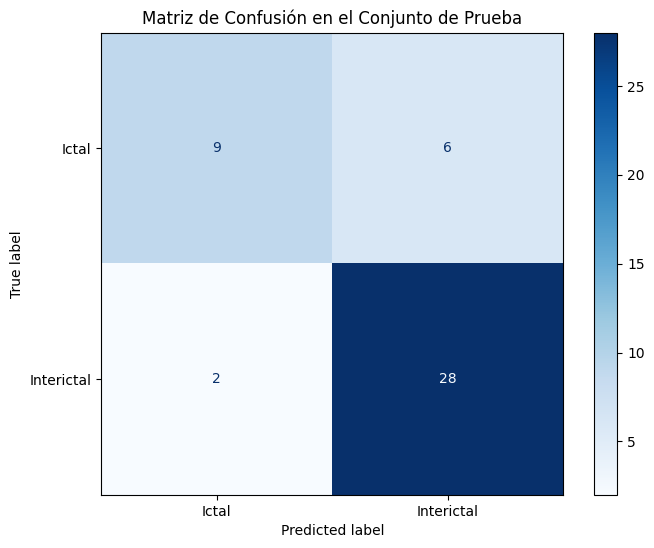


Informe de Clasificación:
              precision    recall  f1-score   support

       Ictal       0.82      0.60      0.69        15
  Interictal       0.82      0.93      0.88        30

    accuracy                           0.82        45
   macro avg       0.82      0.77      0.78        45
weighted avg       0.82      0.82      0.81        45



In [23]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Visualizar la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
display_cm.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusión en el Conjunto de Prueba')
plt.grid(False)
plt.show()

# Imprimir un informe de clasificación detallado
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred, target_names=model.classes_))

## 5. Visualización de señales originales

Se muestran ejemplos representativos de las clases interictal e ictal antes de aplicar cualquier técnica de preprocesamiento.

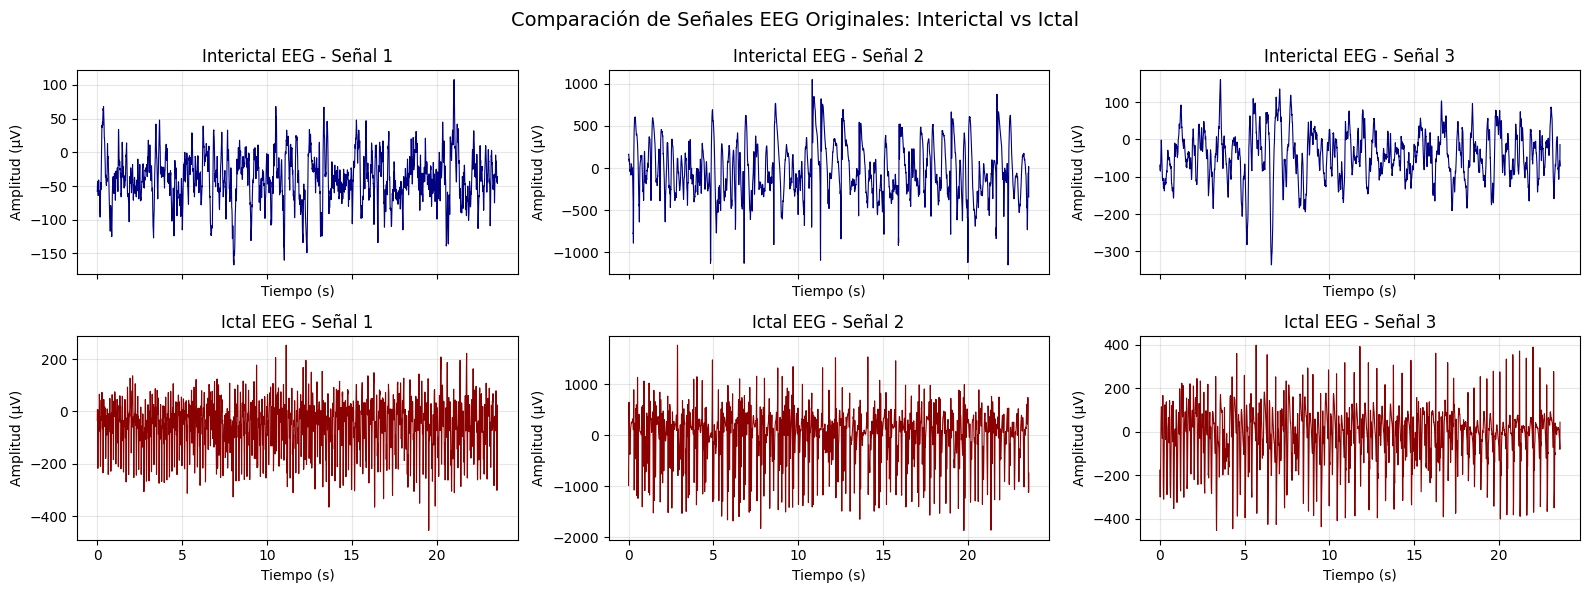

In [25]:
import random

# Selección de señales
interictal_signals = [signals[i] for i in range(len(signals)) if labels[i] == "Interictal"]
ictal_signals = [signals[i] for i in range(len(signals)) if labels[i] == "Ictal"]

n = 3
interictal_sample = random.sample(interictal_signals, n)
ictal_sample = random.sample(ictal_signals, n)

fig, ax = plt.subplots(2, n, figsize=(16, 6), sharex=True)

# Interictal
for i in range(n):
    signal = interictal_sample[i]
    t = np.arange(len(signal))/fs
    ax[0, i].plot(t, signal, color='navy', linewidth=0.8)
    ax[0, i].set_title(f"Interictal EEG - Señal {i+1}")
    ax[0, i].set_xlabel("Tiempo (s)")
    ax[0, i].set_ylabel("Amplitud (µV)")
    ax[0, i].grid(alpha=0.3)

# Ictal
for i in range(n):
    signal = ictal_sample[i]
    t = np.arange(len(signal))/fs
    ax[1, i].plot(t, signal, color='darkred', linewidth=0.8)
    ax[1, i].set_title(f"Ictal EEG - Señal {i+1}")
    ax[1, i].set_xlabel("Tiempo (s)")
    ax[1, i].set_ylabel("Amplitud (µV)")
    ax[1, i].grid(alpha=0.3)

plt.suptitle("Comparación de Señales EEG Originales: Interictal vs Ictal", fontsize=14)
plt.tight_layout()
plt.show()

### 6. Pipeline de Preprocesamiento para Señales EEG

El preprocesamiento es un paso crítico en el análisis de señales biomédicas como el EEG para mejorar la relación señal/ruido, estandarizar los datos y prepararlos para el modelado. Aquí implementaremos y visualizaremos los pasos clave:

*   **Filtrado:** Para eliminar ruido de frecuencias no deseadas.
*   **Normalización:** Para estandarizar la escala de amplitud de las señales.
*   **Consideraciones sobre Segmentación y Eliminación de Artefactos.**
*   **Visualización:** De una señal antes y después del preprocesamiento.

In [32]:
from scipy.signal import butter, lfilter
from sklearn.preprocessing import StandardScaler

# Obtener una señal de ejemplo de cada clase para visualización
# Tomaremos la primera señal 'Interictal' del conjunto de entrenamiento como ejemplo
example_signal_raw = X_train[np.where(y_train == 'Interictal')[0][0]]
example_label = 'Interictal'

print(f"Señal de ejemplo (clase: {example_label}) seleccionada para preprocesamiento.")

Señal de ejemplo (clase: Interictal) seleccionada para preprocesamiento.


### 6.1. Filtrado

Las señales EEG a menudo contienen ruido de baja frecuencia (deriva de la línea base) y de alta frecuencia (ruido muscular, interferencia de la red eléctrica). Un filtro de paso de banda (bandpass filter) es comúnmente usado para retener solo las frecuencias relevantes para la actividad cerebral.

Para este dataset, utilizaremos un filtro Butterworth de paso de banda entre 0.5 Hz y 40 Hz.

In [30]:
def butter_bandpass(lowcut=0.5, highcut=40, fs=fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(signal):
    b, a = butter_bandpass()
    return filtfilt(b, a, signal)

filtered_signals = [bandpass_filter(sig) for sig in signals]


### 6.2. Normalización

La normalización es esencial para muchos algoritmos de aprendizaje automático, especialmente aquellos que son sensibles a la escala de las características (ej., SVM con kernels basados en distancia, redes neuronales). La estandarización (Z-score normalization) es una técnica común que transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Es importante que los parámetros de normalización (media y desviación estándar) se calculen *únicamente* a partir del conjunto de entrenamiento para evitar la fuga de datos.

Aplicaremos la normalización a los conjuntos de entrenamiento, validación y prueba por separado, utilizando el `StandardScaler` de `sklearn`.

Datos filtrados para entrenamiento, validación y prueba.
Datos normalizados para entrenamiento, validación y prueba.


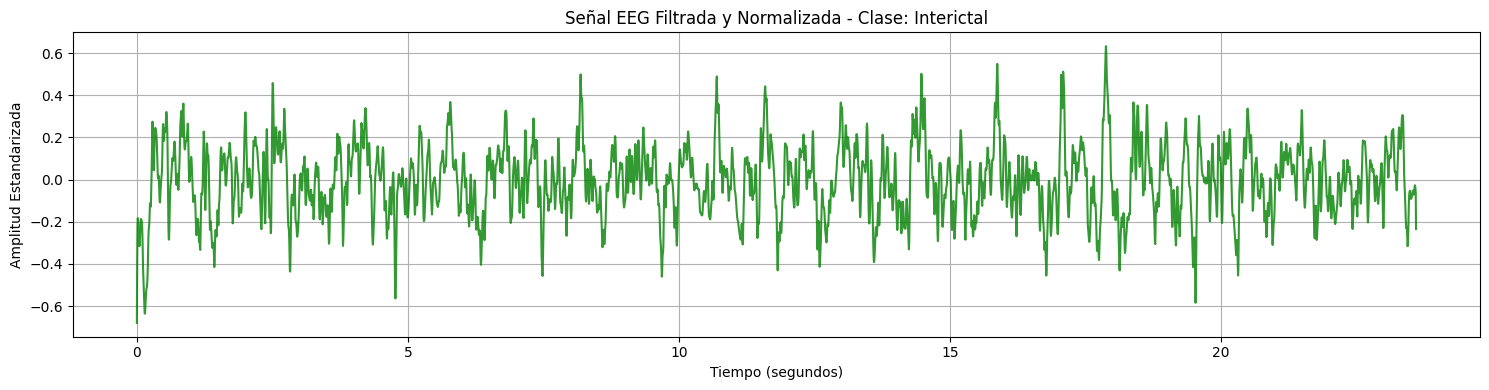


Dimensiones de X_train_scaled: (210, 4097)
Dimensiones de X_val_scaled: (45, 4097)
Dimensiones de X_test_scaled: (45, 4097)


In [33]:
# Primero, aplicar el filtro a los conjuntos de entrenamiento, validación y prueba.
X_train_filtered = np.array([bandpass_filter(signal) for signal in X_train])
X_val_filtered = np.array([bandpass_filter(signal) for signal in X_val])
X_test_filtered = np.array([bandpass_filter(signal) for signal in X_test])

print("Datos filtrados para entrenamiento, validación y prueba.")

scaler = StandardScaler()

# Aplicar normalización Z-score
# Aplicar Fit solo en el conjunto de entrenamiento para evitar data leakage
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_val_scaled = scaler.transform(X_val_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

print("Datos normalizados para entrenamiento, validación y prueba.")

# Preparar la señal de ejemplo para visualización: filtrar y luego normalizar
example_signal_filtered = bandpass_filter(example_signal_raw)
example_signal_filtered_scaled = scaler.transform(example_signal_filtered.reshape(1, -1))[0]

time_vector = np.arange(n_samples) / fs

# Visualización después de filtrado y normalización
plt.figure(figsize=(15, 4))
plt.plot(time_vector, example_signal_filtered_scaled, color='green', alpha=0.8)
plt.title(f'Señal EEG Filtrada y Normalizada - Clase: {example_label}')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud Estandarizada')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nDimensiones de X_train_scaled: {X_train_scaled.shape}")
print(f"Dimensiones de X_val_scaled: {X_val_scaled.shape}")
print(f"Dimensiones de X_test_scaled: {X_test_scaled.shape}")

# 7. Comparación de señales antes y después del preprocesamiento

En esta sección se comparan visualmente las señales EEG en sus tres etapas:

- Señal original
- Señal filtrada (reducción de ruido)
- Señal normalizada (estandarización)

El objetivo es evaluar el impacto del preprocesamiento en dos tipos de actividad cerebral:

- Interictal (actividad entre crisis)
- Ictal (actividad durante la crisis)

Se espera observar:

- Reducción del ruido de alta frecuencia y componentes no deseados
- Mayor estabilidad en la señal tras el filtrado
- Normalización de la amplitud para análisis comparables entre señales

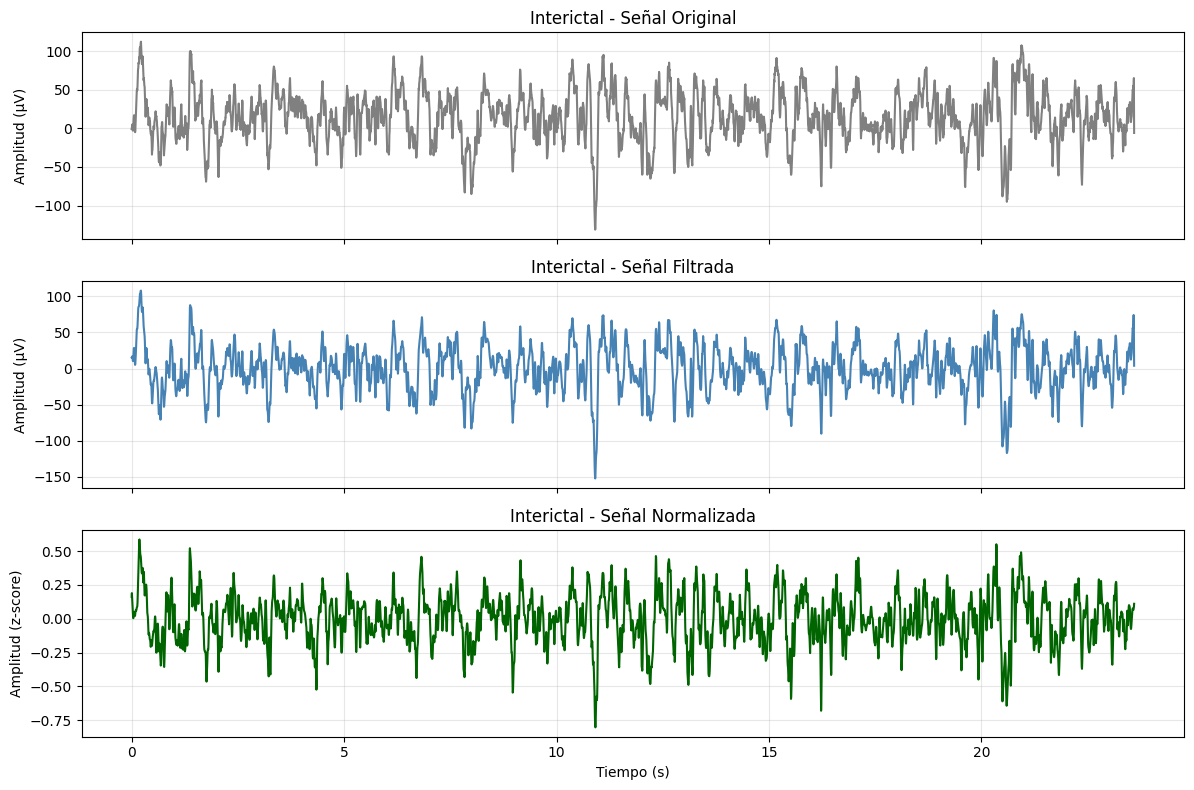

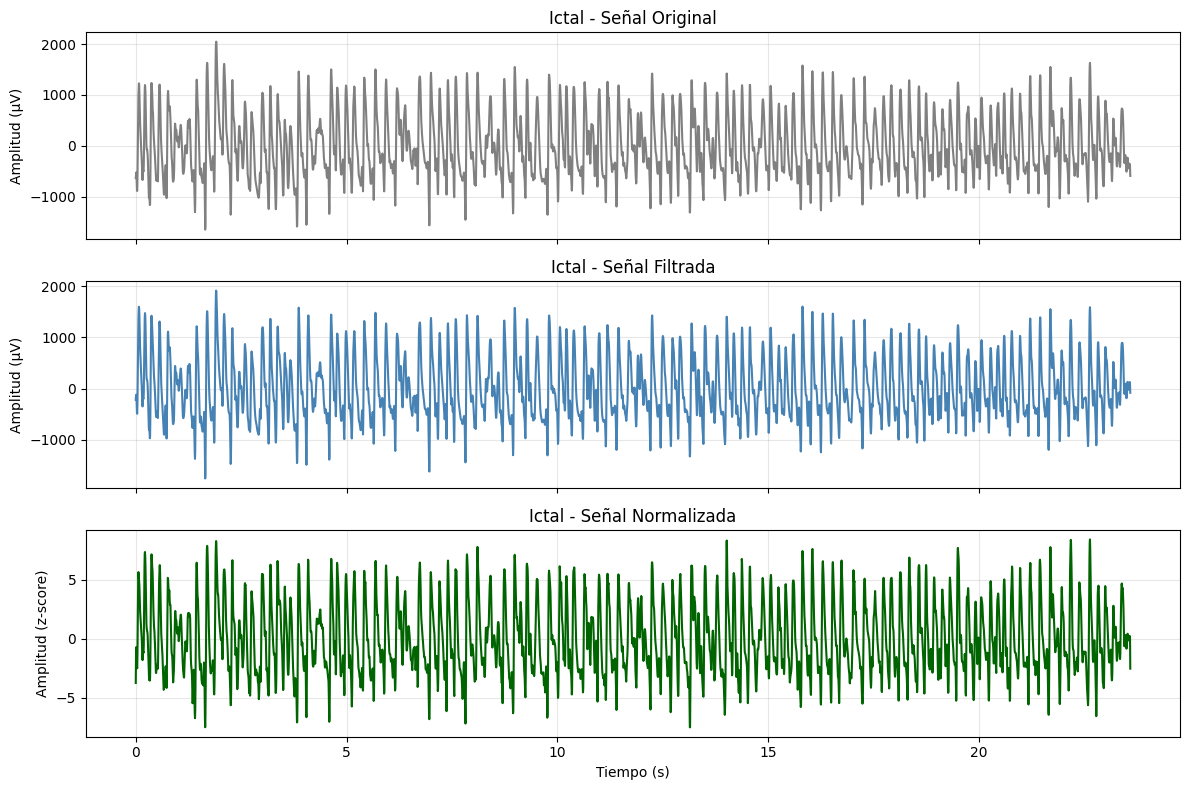

In [35]:
normalized_signals = scaler.transform(np.array(filtered_signals))

# 5.1 INTERICTAL: ORIGINAL / FILTRADA / NORMALIZADA

interictal_idx = [i for i in range(len(labels)) if labels[i] == "Interictal"]
idx = np.random.choice(interictal_idx)

t = np.arange(len(signals[idx])) / fs

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# ORIGINAL
ax[0].plot(t, signals[idx], color='gray')
ax[0].set_title("Interictal - Señal Original")
ax[0].set_ylabel("Amplitud (µV)")
ax[0].grid(alpha=0.3)

# FILTRADA
ax[1].plot(t, filtered_signals[idx], color='steelblue')
ax[1].set_title("Interictal - Señal Filtrada")
ax[1].set_ylabel("Amplitud (µV)")
ax[1].grid(alpha=0.3)

# NORMALIZADA
ax[2].plot(t, normalized_signals[idx], color='darkgreen')
ax[2].set_title("Interictal - Señal Normalizada")
ax[2].set_xlabel("Tiempo (s)")
ax[2].set_ylabel("Amplitud (z-score)")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 5.2 ICTAL: ORIGINAL / FILTRADA / NORMALIZADA

ictal_idx = [i for i in range(len(labels)) if labels[i] == "Ictal"]
idx = np.random.choice(ictal_idx)

t = np.arange(len(signals[idx])) / fs

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# ORIGINAL
ax[0].plot(t, signals[idx], color='gray')
ax[0].set_title("Ictal - Señal Original")
ax[0].set_ylabel("Amplitud (µV)")
ax[0].grid(alpha=0.3)

# FILTRADA
ax[1].plot(t, filtered_signals[idx], color='steelblue')
ax[1].set_title("Ictal - Señal Filtrada")
ax[1].set_ylabel("Amplitud (µV)")
ax[1].grid(alpha=0.3)

# NORMALIZADA
ax[2].plot(t, normalized_signals[idx], color='darkgreen')
ax[2].set_title("Ictal - Señal Normalizada")
ax[2].set_xlabel("Tiempo (s)")
ax[2].set_ylabel("Amplitud (z-score)")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8. Extracción de Características

En esta etapa, las señales EEG se transforman en un conjunto de características numéricas que representan su comportamiento en el dominio del tiempo.

Estas características serán utilizadas posteriormente para el entrenamiento del modelo de clasificación entre señales ictales e interictales.

In [36]:
feature_names = [
    "Media",
    "Std",
    "Mediana",
    "Rango",
    "Asimetria",
    "Curtosis",
    "ZeroCrossingRate",
]

def extract_features(sig):
    zcr = np.sum(np.diff(np.sign(sig)) != 0) / len(sig)
    return [np.mean(sig), np.std(sig), np.median(sig), np.max(sig) - np.min(sig), skew(sig), kurtosis(sig),zcr,]

# Features antes del preprocesamiento
X_before = [extract_features(sig) for sig in signals]
df_before = pd.DataFrame(X_before, columns=feature_names)
df_before["Clase"] = labels

# Features después del preprocesamiento
X_after = [extract_features(sig) for sig in normalized_signals]
df_after = pd.DataFrame(X_after, columns=feature_names)
df_after["Clase"] = labels


print("Before:", df_before.shape)
print("After:", df_after.shape)

Before: (300, 8)
After: (300, 8)


In [37]:
print("Características antes del preprocesamiento")
display(df_before.groupby("Clase")[feature_names].mean())

print("\nCaracterísticas después del preprocesamiento")
display(df_after.groupby("Clase")[feature_names].mean())

antes = df_before.groupby("Clase")[feature_names].mean()
antes["Estado"] = "Antes"

despues = df_after.groupby("Clase")[feature_names].mean()
despues["Estado"] = "Después"

comparacion = pd.concat([antes, despues])

print("\nComparativa general")
display(comparacion)

Características antes del preprocesamiento


,Media,Std,Mediana,Rango,Asimetria,Curtosis,ZeroCrossingRate
Clase,,,,,,,
Ictal,-4.748914,306.572692,6.67,1858.96,-0.059880,0.428355,0.081665
Interictal,-7.541523,58.221846,-8.57,431.24,-0.036874,0.983903,0.065638



Características después del preprocesamiento


,Media,Std,Mediana,Rango,Asimetria,Curtosis,ZeroCrossingRate
Clase,,,,,,,
Ictal,0.003166,1.559963,0.056948,9.892872,-0.057092,0.372113,0.080661
Interictal,-0.003092,0.299317,-0.005321,2.381314,-0.061120,1.140998,0.072360



Comparativa general


,Media,Std,Mediana,Rango,Asimetria,Curtosis,ZeroCrossingRate,Estado
Clase,,,,,,,,
Ictal,-4.748914,306.572692,6.670000,1858.960000,-0.059880,0.428355,0.081665,Antes
Interictal,-7.541523,58.221846,-8.570000,431.240000,-0.036874,0.983903,0.065638,Antes
Ictal,0.003166,1.559963,0.056948,9.892872,-0.057092,0.372113,0.080661,Después
Interictal,-0.003092,0.299317,-0.005321,2.381314,-0.061120,1.140998,0.072360,Después


/tmp/ipykernel_666/2786533571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_after, x="Clase", y=feature, palette=["steelblue", "firebrick"])


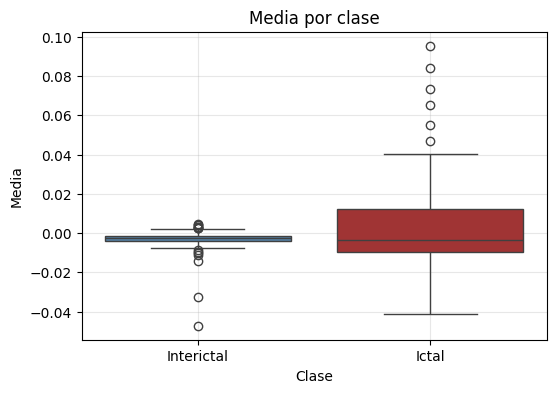

/tmp/ipykernel_666/2786533571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_after, x="Clase", y=feature, palette=["steelblue", "firebrick"])


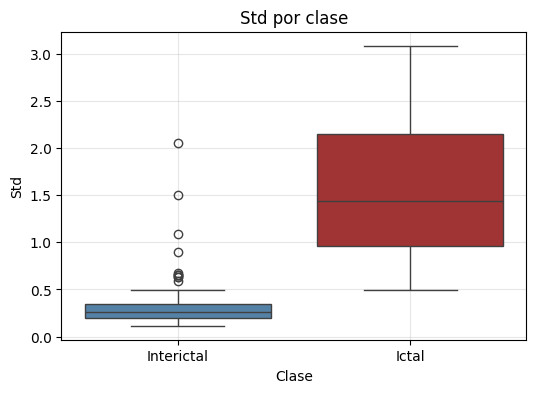

/tmp/ipykernel_666/2786533571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_after, x="Clase", y=feature, palette=["steelblue", "firebrick"])


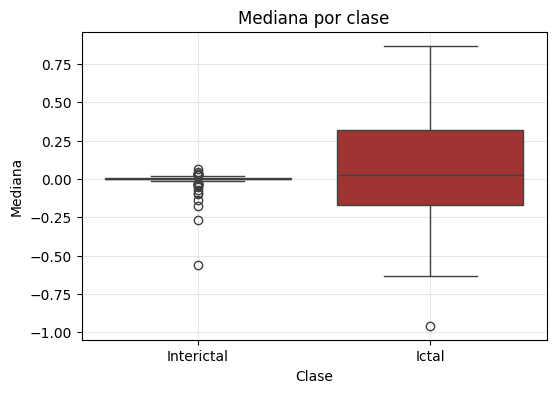

/tmp/ipykernel_666/2786533571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_after, x="Clase", y=feature, palette=["steelblue", "firebrick"])


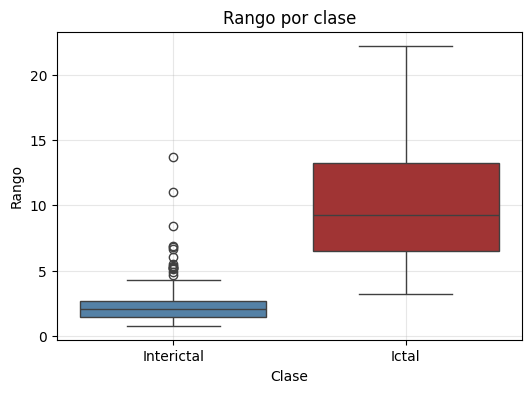

/tmp/ipykernel_666/2786533571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_after, x="Clase", y=feature, palette=["steelblue", "firebrick"])


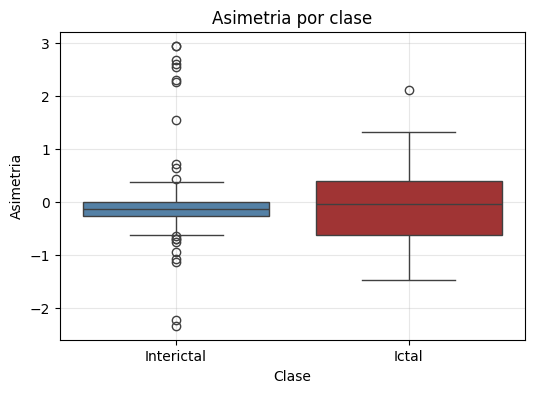

/tmp/ipykernel_666/2786533571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_after, x="Clase", y=feature, palette=["steelblue", "firebrick"])


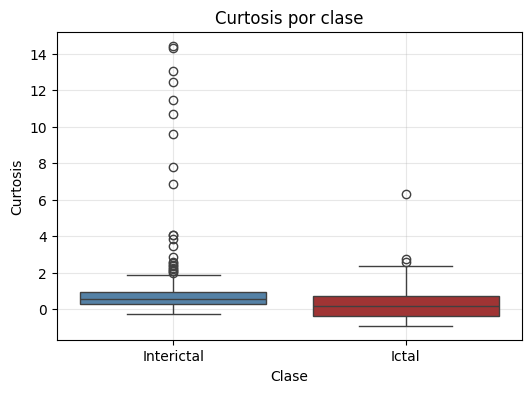

/tmp/ipykernel_666/2786533571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_after, x="Clase", y=feature, palette=["steelblue", "firebrick"])


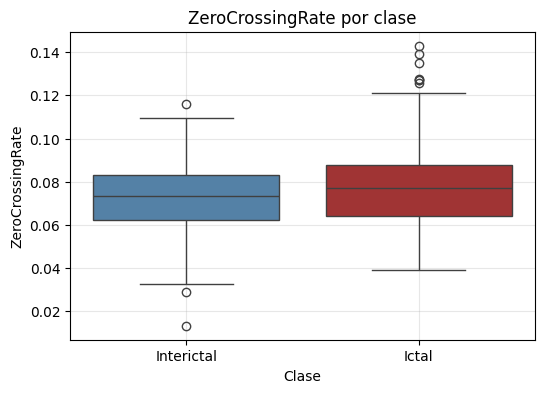

In [38]:
for feature in feature_names:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df_after, x="Clase", y=feature, palette=["steelblue", "firebrick"])
    plt.title(f"{feature} por clase")
    plt.grid(alpha=0.3)
    plt.show()